## 1. Download and load the Student Performance dataset.


In [42]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")

# Display first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [43]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

In this task, the Student Performance dataset is loaded into a Pandas DataFrame. The dataset is then inspected to understand its structure, dimensions, and available features.

## 2.Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.  

Data preprocessing is performed to prepare the dataset for model training. This includes checking for missing values, encoding categorical variables into numerical format, and applying feature scaling to ensure efficient convergence of the Gradient Descent algorithm.


In [44]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


The dataset is examined for missing or null values to ensure data quality before training the model.

In [45]:
df = pd.get_dummies(df, drop_first=True)

print("Dataset Shape After Encoding:", df.shape)

Dataset Shape After Encoding: (395, 42)


Categorical features are converted into numerical values using one-hot encoding, making them suitable.

## 3.Select appropriate input features and the target variable.


In [46]:
X = df.drop("G3", axis=1)

y = df["G3"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (395, 41)
Target Shape: (395,)


The input features (X) and the target variable (y) are selected. In this experiment, the final student grade (G3) is chosen as the target variable.

##  4.Split the dataset into training and testing sets.


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset is divided into training and testing subsets using an 80:20 ratio. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


The numerical features are standardized using StandardScaler to improve the convergence speed and stability of the Gradient Descent optimization algorithm.

## 5.Implement Linear Regression using the Gradient Descent algorithm.


In [49]:
import numpy as np

class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):

        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0

        self.loss_history = []

        for i in range(self.iterations):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = (1/(2*m)) * np.sum((y_pred - y)**2)

            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [50]:
model = LinearRegressionGD(
    learning_rate=0.01,
    iterations=1000
)

model.fit(X_train, y_train)

A Linear Regression model is implemented from scratch using the Gradient Descent optimization algorithm. The model iteratively updates the weights and bias to minimize the cost function.

## 6.Experiment with different learning rates and observe their effect on model convergence.


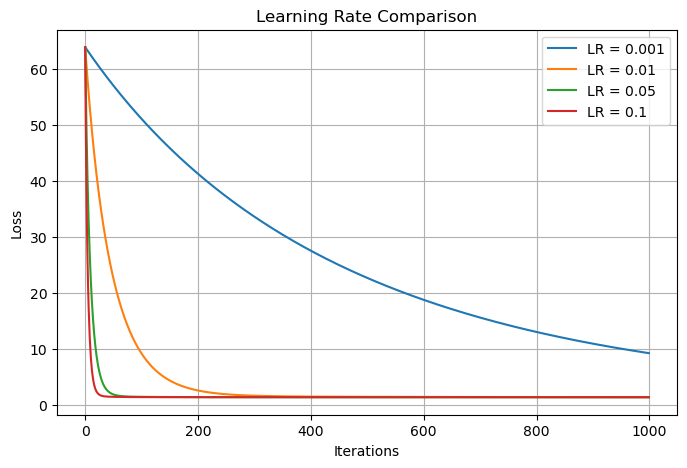

In [51]:
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.05, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    model = LinearRegressionGD(
        learning_rate=lr,
        iterations=1000
    )

    model.fit(X_train, y_train)

    plt.plot(model.loss_history, label=f"LR = {lr}")

plt.title("Learning Rate Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Different learning rates are tested to observe their effect on the convergence speed and stability of the Gradient Descent algorithm.

## 7.Plot the loss (cost) versus the number of iterations.


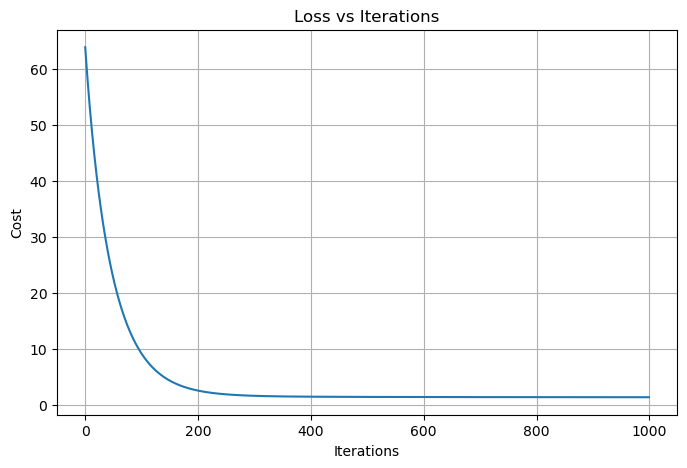

In [52]:
model = LinearRegressionGD(
    learning_rate=0.01,
    iterations=1000
)

model.fit(X_train, y_train)

plt.figure(figsize=(8,5))

plt.plot(model.loss_history)

plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)

plt.show()

The variation of the cost function over successive iterations is visualized to analyze the convergence behavior of the Gradient Descent algorithm.

## 8.Evaluate the trained model using:
### Mean Absolute Error (MAE)
### Mean Squared Error (MSE)
### Root Mean Squared Error (RMSE)
### R² Score


In [53]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.6700289430321864
Mean Squared Error (MSE): 5.6936391694756425
Root Mean Squared Error (RMSE): 2.386134776050096
R² Score: 0.7223298685908052


The trained Linear Regression model is evaluated using standard regression metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score.

The Linear Regression model was successfully implemented using the Gradient Descent optimization algorithm. The loss decreased rapidly during the initial iterations and gradually stabilized after approximately 300 iterations, indicating that the Gradient Descent algorithm successfully converged to a minimum.

The learning rate comparison showed that the convergence speed depends on the chosen learning rate. A learning rate of **0.001** converged slowly, whereas **0.01**, **0.05**, and **0.1** converged much faster. Among the tested values, **0.1** achieved the fastest convergence without showing instability or divergence.

The model achieved a **Mean Absolute Error (MAE)** of **1.67**, indicating that the predicted final grades differ from the actual grades by approximately **1.67 marks** on average. The **Mean Squared Error (MSE)** was **5.69**, and the **Root Mean Squared Error (RMSE)** was **2.38**, indicating relatively low prediction errors. The model obtained an **R² Score of 0.72**, which means it explains approximately **72.23%** of the variation in students' final grades.

Overall, the Gradient Descent algorithm successfully optimized the Linear Regression model, demonstrating effective convergence and good prediction performance on the Student Performance dataset.